In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

In [ ]:
import pandas as pd
df = pd.read_csv('/content/Credit_card.csv')
df.head()

,Ind_ID,GENDER,Car_Owner,Propert_Owner,CHILDREN,Annual_income,Type_Income,EDUCATION,Marital_status,Housing_type,Birthday_count,Employed_days,Mobile_phone,Work_Phone,Phone,EMAIL_ID,Type_Occupation,Family_Members
0,5008827,M,Y,Y,0,180000.0,Pensioner,Higher education,Married,House / apartment,-18772.0,365243,1,0,0,0,NaN,2
1,5009744,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,-13557.0,-586,1,1,1,0,NaN,2
2,5009746,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,NaN,-586,1,1,1,0,NaN,2
3,5009749,F,Y,N,0,NaN,Commercial associate,Higher education,Married,House / apartment,-13557.0,-586,1,1,1,0,NaN,2
4,5009752,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,-13557.0,-586,1,1,1,0,NaN,2
5,5009753,NaN,Y,N,0,315000.0,Pensioner,Higher education,Married,House / apartment,-13557.0,-586,1,1,1,0,NaN,2
6,5009754,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,-13557.0,-586,1,1,1,0,NaN,2
7,5009894,F,N,N,0,180000.0,Pensioner,Secondary / secondary special,Married,House / apartment,-22134.0,365243,1,0,0,0,NaN,2
8,5010864,M,Y,Y,1,450000.0,Commercial associate,Secondary / secondary special,Married,House / apartment,-18173.0,-678,1,0,1,1,Core staff,3
9,5010868,M,Y,Y,1,450000.0,Pensioner,Secondary / secondary special,Married,House / apartment,-18173.0,-678,1,0,1,1,Core staff,3


In [ ]:
df['Type_Income'].value_counts()

,count
Type_Income,
Working,798
Commercial associate,365
Pensioner,269
State servant,116


In [ ]:
missing_income_rows = df['Annual_income'].isna()
df_cleaned = df[~missing_income_rows].copy()

x = df_cleaned.drop('Annual_income', axis=1)
y = df_cleaned['Annual_income']

x_train, x_test, y_train, y_test = train_test_split(
    x,y, test_size=0.2, random_state=42
)


In [ ]:
from sklearn.dummy import DummyRegressor # Changed to DummyRegressor
from sklearn.metrics import mean_squared_error # Changed to a regression metric

# Initialize Dummy Regressor with 'mean' strategy (common for regression baselines)
dummy_reg = DummyRegressor(strategy='mean')

# Train the regressor
dummy_reg.fit(x_train, y_train)
print("Baseline Mean Squared Error:", mean_squared_error(y_test, dummy_reg.predict(x_test)))


Baseline Mean Squared Error: 8757886803.61673


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier

pipeline = Pipeline([
  ('scaler', StandardScaler()),
  ('knn', KNeighborsClassifier())
])

In [ ]:
param_grid = {
    'knn__n_neighbors': list(range(1,21)),
    'knn__weights': ['uniform', 'distance'],
    'knn__p': [1,2]
}

In [ ]:
grid = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy', n_jobs=-1
)

grid.fit(x_train, y_train)
grid.best_params_

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


ValueError: 
All the 400 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
80 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py", line 654, in fit
    Xt = self._fit(X, y, routed_params, raw_params=params)
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py", line 588, in _fi

In [ ]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)
print("Train-test split re-initialized successfully.")

Train-test split re-initialized successfully.


In [ ]:
numerical_cols = x_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = x_train.select_dtypes(include=['object', 'bool']).columns.tolist()

print("Numerical Columns:", numerical_cols)
print("Categorical Columns:", categorical_cols)

Numerical Columns: ['Ind_ID', 'CHILDREN', 'Birthday_count', 'Employed_days', 'Mobile_phone', 'Work_Phone', 'Phone', 'EMAIL_ID', 'Family_Members']
Categorical Columns: ['GENDER', 'Car_Owner', 'Propert_Owner', 'Type_Income', 'EDUCATION', 'Marital_status', 'Housing_type', 'Type_Occupation']


In [ ]:
from sklearn.model_selection import GridSearchCV

grid = GridSearchCV(pipeline, param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)

grid.fit(x_train, y_train)
print("Best parameters found: ", grid.best_params_)

Best parameters found:  {'knn__n_neighbors': 20, 'knn__p': 1, 'knn__weights': 'distance'}


In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

best_model = grid.best_estimator_
y_pred = best_model.predict(x_test)

print("Test Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("Test R2 Score:", r2_score(y_test, y_pred))


Test Mean Squared Error: 5527136061.244217
Test R2 Score: 0.3440845808785612


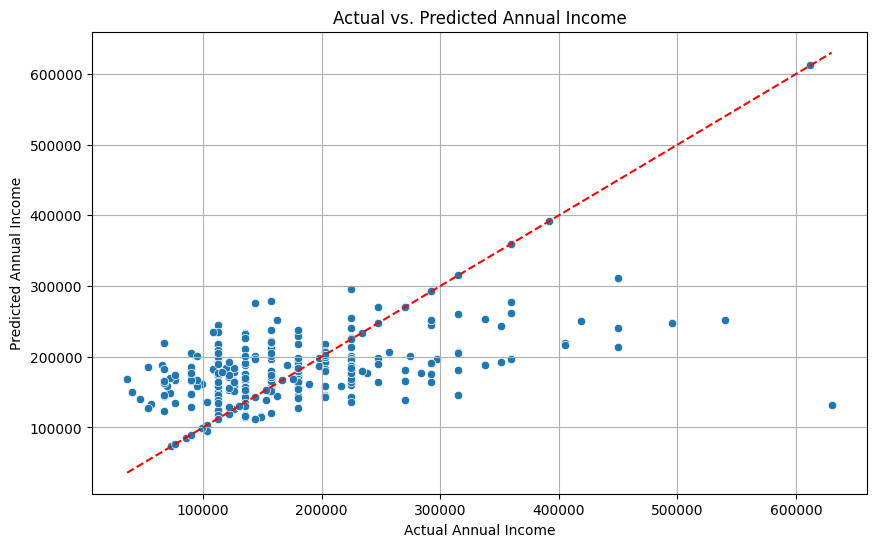

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel('Actual Annual Income')
plt.ylabel('Predicted Annual Income')
plt.title('Actual vs. Predicted Annual Income')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--') # Identity line
plt.grid(True)
plt.show()